In [236]:
import sys
import os
import matplotlib.pyplot as plt
import networkx as nx
import json

# Add the parent directory to the path to import from src
sys.path.append(os.path.abspath(".."))
from concept_creator.critical_point_concept_service import (
    CriticalPointConceptService,
)

# Configuration
uri = "bolt://localhost:7687"
user = "neo4j"
password = "111122223333"
session_id = "9_2"
concept_name = session_id



In [237]:
# Create the concept with visualization
service = CriticalPointConceptService(uri, user, password)
concept_id, concept_graph = service.create_concept_incrementally(
    session_id, concept_name
)

INFO:root:Initializing ConceptCreationRepository
INFO:root:Database connection established
INFO:concept_creator.critical_point_concept_service:CriticalPointConceptService initialized.
INFO:concept_creator.critical_point_concept_service:Creating concept for session 9_2 using Critical Point approach.
INFO:root:Getting image IDs for session 9_2
INFO:concept_creator.critical_point_concept_service:Initialized concept with graph from image 1788b4c2-4957-4856-a6e5-c0d931cf2b42. Nodes: 16
INFO:concept_creator.critical_point_concept_service:Processing image 2/2: 6aaf77bd-7c67-4981-8d59-2bb612a4ff49
INFO:concept_creator.graph_minor_finder:Finding maximum common minor between graphs: concept (16 nodes) and image (16 nodes)
INFO:concept_creator.critical_point_preprocessor:Preprocessing graphs for critical point compatibility
INFO:concept_creator.critical_point_preprocessor:Graph1 critical points: {'IntersectionPoint': 1, 'CornerPoint': 1, 'EndPoint': 0, 'StartPoint': 1}
INFO:concept_creator.critic

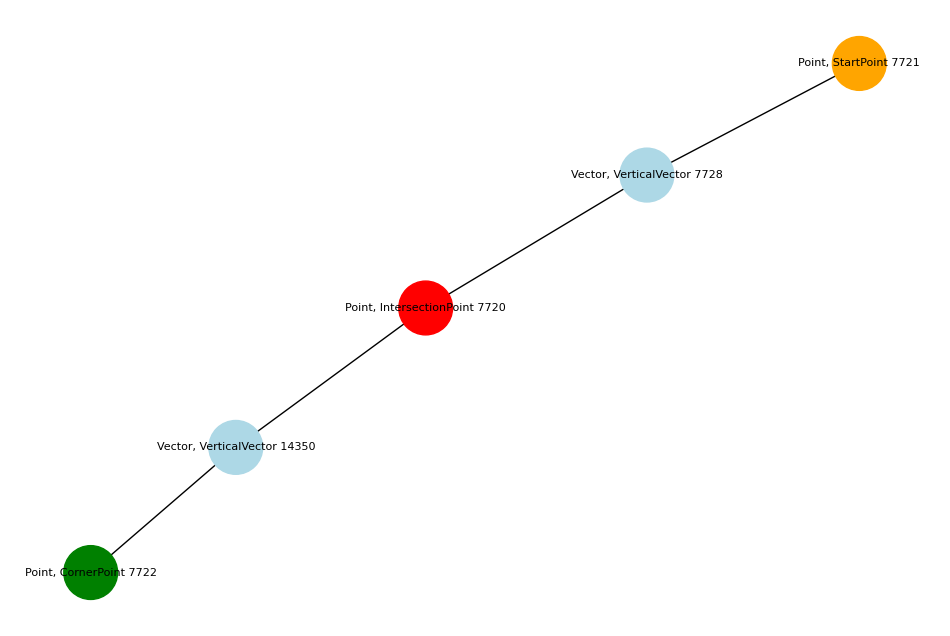

In [238]:
# Create a new figure
plt.figure(figsize=(12, 8))

node_to_color = {
    "IntersectionPoint": "red",
    "CornerPoint": "green",
    "EndPoint": "blue",
    "QuadrantChangePoint": "purple",
    "StartPoint": "orange"
}

# Get node colors based on node labels
node_colors = []
labels_for_nodes = {}

for node in concept_graph.nodes():
    # Get labels from node attributes - try different ways to access labels
    node_data = concept_graph.nodes[node]
    
    # First, try to get labels as a direct attribute
    labels = node_data.get('labels', [])
    
    # If labels is empty, try to get them from node_labels attribute
    if not labels and 'node_labels' in node_data:
        labels = node_data['node_labels']
    
    # If still empty, check if any attribute has 'label' in its name
    if not labels:
        for key in node_data:
            if 'label' in key.lower() and node_data[key]:
                if isinstance(node_data[key], list):
                    labels = node_data[key]
                else:
                    labels = [str(node_data[key])]
                break
    
    # If everything fails, use a default label
    if not labels:
        labels = ["Point"]
    
    # Store labels for node labeling
    labels_for_nodes[node] = ', '.join(str(label) for label in labels) + ' ' + str(node.split(':')[-1]) if labels else str(node)
    
    # Check if any label matches our color mapping
    color = 'lightblue'  # Default color
    for label in labels:
        label_str = str(label)  # Convert to string if it's not already
        if label_str in node_to_color:
            color = node_to_color[label_str]
            break
    
    node_colors.append(color)

# Draw the graph with explicit node_color parameter
pos = nx.spring_layout(concept_graph)  # Calculate positions
nx.draw_networkx_nodes(concept_graph, pos, node_color=node_colors, node_size=1500)
nx.draw_networkx_edges(concept_graph, pos)
nx.draw_networkx_labels(concept_graph, pos, labels=labels_for_nodes, font_size=8)
plt.axis('off')
plt.show()

In [239]:
# Printing the graph properties per node
for node in concept_graph.nodes():
    print(f"Node {node}: {concept_graph.nodes[node]}")

# Create a directory for saved graphs if it doesn't exist
save_dir = "saved_graphs"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Convert the graph to a JSON-serializable format
graph_data = nx.node_link_data(concept_graph)

# Save the graph with a descriptive filename
json_filename = os.path.join(save_dir, "concept_graph.json")
with open(json_filename, "w") as f:
    json.dump(graph_data, f, indent=2)

print(f"Graph saved to {json_filename} in JSON format")



Node 4:95f7de00-19a5-43d7-b929-cea0efad5c70:7721: {'labels': ['Point', 'StartPoint'], 'endpoints_count': 0, 'normalized_x': {'min': 0.3, 'max': 0.4, 'type': 'range', 'center': 0.35000000000000003}, 'x': {'min': 66.00000000000003, 'max': 70.99999999999997, 'type': 'range', 'center': 68.5}, 'cycle_count': 1, 'corner_points_count': 2, 'relative_distance': 0.6, 'normalized_y': 0.7, 'segments': ['bottom', 'right'], 'monotony': 'NON_MONOTONIC', 'intersection_points_count': 1, 'vectors_count': 8, 'y': {'min': 86.37053836753353, 'max': 87.3927265500187, 'type': 'range', 'center': 86.88163245877612}, 'session_id': '9_2', 'contour_type': 'OPEN', 'quadrant_change_count': 4}
Node 4:95f7de00-19a5-43d7-b929-cea0efad5c70:7728: {'labels': ['Vector', 'VerticalVector'], 'direction_sequence_index': 0, 'segments': ['bottom', 'right'], 'monotony': 'NON_MONOTONIC', 'intersection_points_count': 1, 'vectors_count': 8, 'session_id': '9_2', 'normalized_x': {'min': 0.3, 'max': 0.4, 'type': 'range', 'center': 0.3

TypeError: Object of type set is not JSON serializable